In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.getenv("REDDIT_CODE_DIR"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from reddit_helpers import *

pd.set_option("display.max_colwidth", 120)
np.set_printoptions(precision=3, suppress=True)

In [2]:
SUBREDDITS     = ["Christianity", "atheism", "DebateReligion"]
N_PER_SUB      = 150
MIN_TEXT_WORDS = 10
RANDOM_SEED    = 42

In [3]:
def _clean_field(x):
    if x is None:
        return ""
    if isinstance(x, float) and np.isnan(x):
        return ""
    return str(x).strip()


def make_post_text(row):
    selftext = _clean_field(row.get("selftext"))
    if selftext and selftext not in ("[deleted]", "[removed]"):
        return " ".join(selftext.split())
    return ""


def load_pool(subreddit, n=N_PER_SUB, seed=RANDOM_SEED):
    df = load_subreddit(subreddit, load="posts", slim=True, clean=True)
    df = df.copy()
    df["text"] = df.apply(make_post_text, axis=1)
    df = df[df["text"].str.split().str.len() >= MIN_TEXT_WORDS]
    df = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)
    df["subreddit"] = subreddit
    return df

In [4]:
df_all = pd.concat([load_pool(sub) for sub in SUBREDDITS], ignore_index=True)

print(f"Total posts loaded: {len(df_all)}")
df_all.groupby("subreddit").size()

Total posts loaded: 450


subreddit
Christianity      150
DebateReligion    150
atheism           150
dtype: int64

In [5]:
df_all

,id,subreddit,author,created_utc,title,selftext,num_comments,text
0,2axmih,Christianity,coolscreenname,2014-07-17 06:31:03,Missionary doctor in ICU... as a patient.,Friends of mine have a son who was prepping to go to India to practice as a medical missionary.\n\n\n\n\nHe has been...,2,Friends of mine have a son who was prepping to go to India to practice as a medical missionary. He has been terribly...
1,rmod04,Christianity,OneImagination9301,2021-12-23 05:37:49,Mission Trips,"Hey, so I’m having doubts about going on this mission trip to Philadelphia with my college group . It’s not so much ...",14,"Hey, so I’m having doubts about going on this mission trip to Philadelphia with my college group . It’s not so much ..."
2,ecigu1,Christianity,scarface4tx,2019-12-18 20:53:59,Protestant-Catholic marriage: good idea?,I’m a never-married evangelical man (late 20’s) about to start dating again after a long break.\nShould I be open to...,63,I’m a never-married evangelical man (late 20’s) about to start dating again after a long break. Should I be open to ...
3,1df3cqw,Christianity,Bryang36ff,2024-06-13 16:36:30,Baptism for Infants,"Question, what does the baptism of an infant symbolize, and is it a commitment to attend and raise the child in chur...",6,"Question, what does the baptism of an infant symbolize, and is it a commitment to attend and raise the child in chur..."
4,1e17wfo,Christianity,girl1723,2024-07-12 03:43:25,I believe in God and the Holy Bible but dont believe in attending church. What am i?,I believe in God and the Holy Bible but dont believe in attending church. What am i?\n\nLittle back story.. I was ra...,9,I believe in God and the Holy Bible but dont believe in attending church. What am i? Little back story.. I was raise...
...,...,...,...,...,...,...,...,...
445,1q281o9,DebateReligion,Man_for_Meaning98,2026-01-02 19:28:02,Any Debate Recommendations Concerning Qur'an Scientific Discoveries and Eucharistic Miracles,"I'm (m27 agnostic) am currently researching faith and religion, with it being a key aim of this year. For context I ...",12,"I'm (m27 agnostic) am currently researching faith and religion, with it being a key aim of this year. For context I ..."
446,1s5h7nw,DebateReligion,No-Usual1515,2026-03-27 21:28:01,Humanism is the biggest threat to humanity.,"When you think of the end of the world, what do you imagine?\n\nHow are the people? Are they mean and openly hostile...",95,"When you think of the end of the world, what do you imagine? How are the people? Are they mean and openly hostile? A..."
447,ewjtir,DebateReligion,drewr007,2020-01-31 05:55:11,Gods truth could never be written in a book,Think of the most profound experience of your life. Do words do it justice? Could you have just read about it instea...,18,Think of the most profound experience of your life. Do words do it justice? Could you have just read about it instea...
448,1a5fxs,DebateReligion,shwag945,2013-03-12 15:24:10,To Catholics: What changes do you want to see a new Pope enacting in your church?,Another way I could phrase this question: If you were elected as Pope today what would you change immediately upon t...,16,Another way I could phrase this question: If you were elected as Pope today what would you change immediately upon t...


In [6]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

def _vader_label(c):
    if c >=  0.05: return "positive"
    if c <= -0.05: return "negative"
    return "neutral"

df_all["vader_compound"] = df_all["text"].apply(lambda t: sia.polarity_scores(t)["compound"])
df_all["vader_label"]    = df_all["vader_compound"].map(_vader_label)

print(f"VADER done — {len(df_all)} posts")
df_all.groupby(["subreddit", "vader_label"]).size().unstack(fill_value=0)

VADER done — 450 posts


vader_label,negative,neutral,positive
subreddit,,,
Christianity,44,4,102
DebateReligion,51,4,95
atheism,48,11,91


In [7]:
from transformers import pipeline as hf_pipeline
from tqdm.notebook import tqdm

roberta_pipe = hf_pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512,
)

BATCH_SIZE = 16
texts = df_all["text"].tolist()
raw   = []
for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="RoBERTa"):
    raw.extend(roberta_pipe(texts[i : i + BATCH_SIZE]))

df_all["roberta_label"]  = [r["label"] for r in raw]
df_all["roberta_score"]  = [r["score"]  for r in raw]
df_all["roberta_signed"] = [
     r["score"]  if r["label"] == "positive" else
    -r["score"]  if r["label"] == "negative" else 0.0
    for r in raw
]

print(f"RoBERTa done — {len(df_all)} posts")
df_all.groupby(["subreddit", "roberta_label"]).size().unstack(fill_value=0)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa:   0%|          | 0/29 [00:00<?, ?it/s]

RoBERTa done — 450 posts


roberta_label,negative,neutral,positive
subreddit,,,
Christianity,48,77,25
DebateReligion,54,92,4
atheism,52,76,22


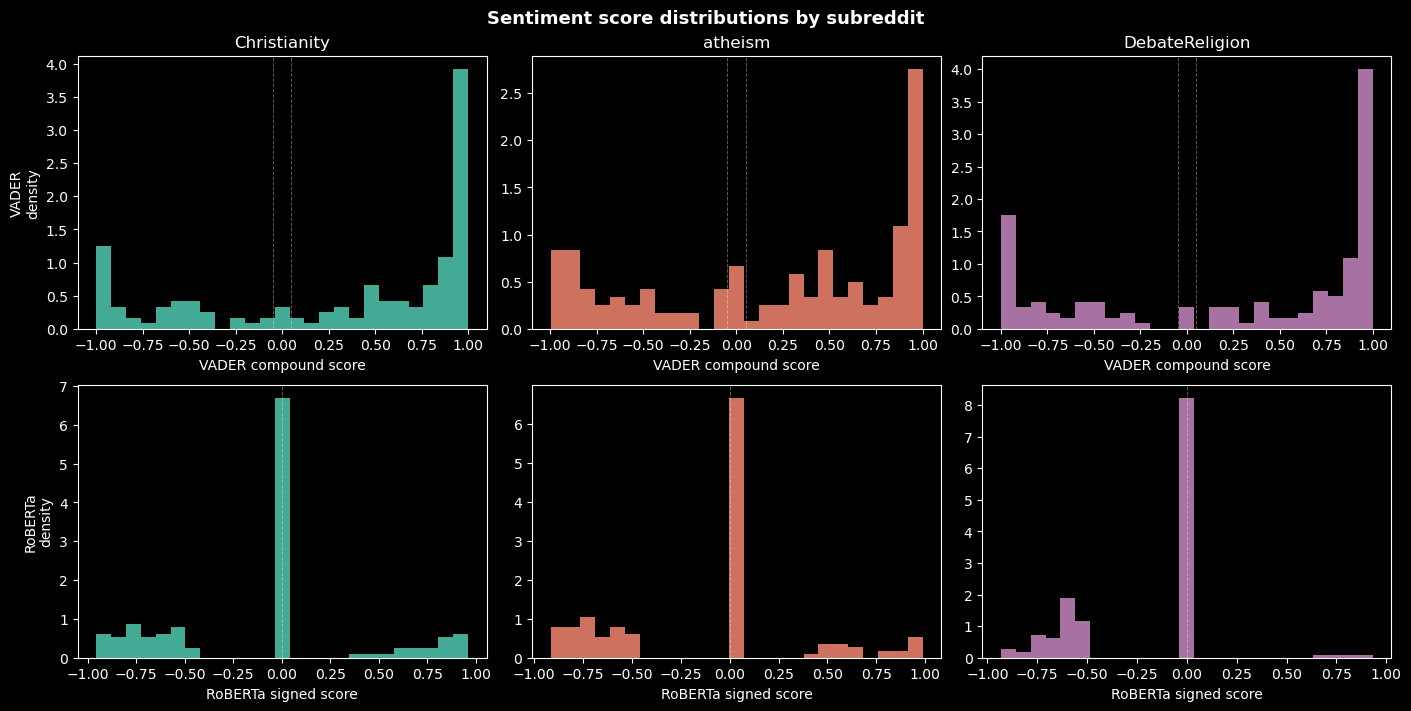

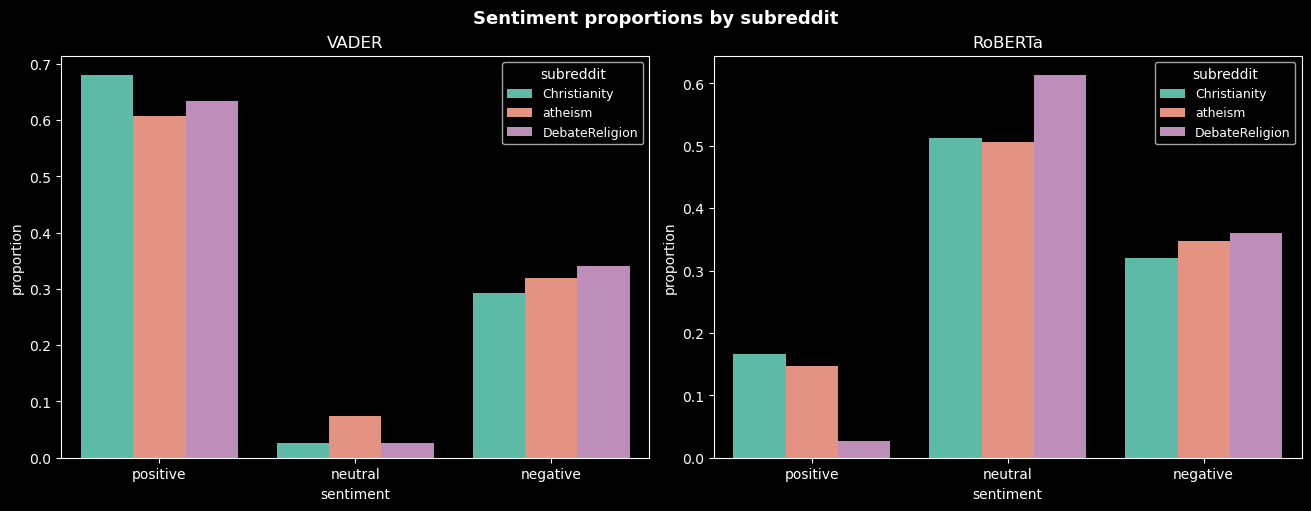

In [8]:
import seaborn as sns

plt.style.use("dark_background")

SUBREDDITS = df_all["subreddit"].unique().tolist()
LABELS     = ["positive", "neutral", "negative"]
SUB_COLORS = {"Christianity": "#4ec9b0", "atheism": "#f48771", "DebateReligion": "#c586c0"}

# ── Figure 1: per-subreddit histograms ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
fig.suptitle("Sentiment score distributions by subreddit", fontsize=13, weight="bold")

for col, sub in enumerate(SUBREDDITS):
    mask  = df_all["subreddit"] == sub
    color = SUB_COLORS[sub]

    ax = axes[0, col]
    ax.hist(df_all.loc[mask, "vader_compound"], bins=25, color=color, alpha=0.85, density=True)
    ax.axvline( 0.05, color="white", lw=0.7, ls="--", alpha=0.35)
    ax.axvline(-0.05, color="white", lw=0.7, ls="--", alpha=0.35)
    ax.set_title(sub)
    ax.set_xlabel("VADER compound score")
    if col == 0:
        ax.set_ylabel("VADER\ndensity")

    ax = axes[1, col]
    ax.hist(df_all.loc[mask, "roberta_signed"], bins=25, color=color, alpha=0.85, density=True)
    ax.axvline(0, color="white", lw=0.7, ls="--", alpha=0.35)
    ax.set_xlabel("RoBERTa signed score")
    if col == 0:
        ax.set_ylabel("RoBERTa\ndensity")

plt.show()

# ── Figure 2: sentiment proportions — seaborn grouped bar (hue = subreddit) ──
palette = {sub: SUB_COLORS[sub] for sub in SUBREDDITS}

vader_long = (
    df_all.groupby(["subreddit", "vader_label"]).size()
    .reset_index(name="count")
    .assign(proportion=lambda d: d["count"] / d.groupby("subreddit")["count"].transform("sum"))
    .rename(columns={"vader_label": "sentiment"})
)
roberta_long = (
    df_all.groupby(["subreddit", "roberta_label"]).size()
    .reset_index(name="count")
    .assign(proportion=lambda d: d["count"] / d.groupby("subreddit")["count"].transform("sum"))
    .rename(columns={"roberta_label": "sentiment"})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle("Sentiment proportions by subreddit", fontsize=13, weight="bold")

for ax, data, title in [
    (axes[0], vader_long,   "VADER"),
    (axes[1], roberta_long, "RoBERTa"),
]:
    sns.barplot(data=data, x="sentiment", y="proportion", hue="subreddit",
                palette=palette, order=LABELS, hue_order=SUBREDDITS,
                errorbar=None, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("sentiment")
    ax.set_ylabel("proportion")
    ax.legend(title="subreddit", fontsize=9)

plt.show()

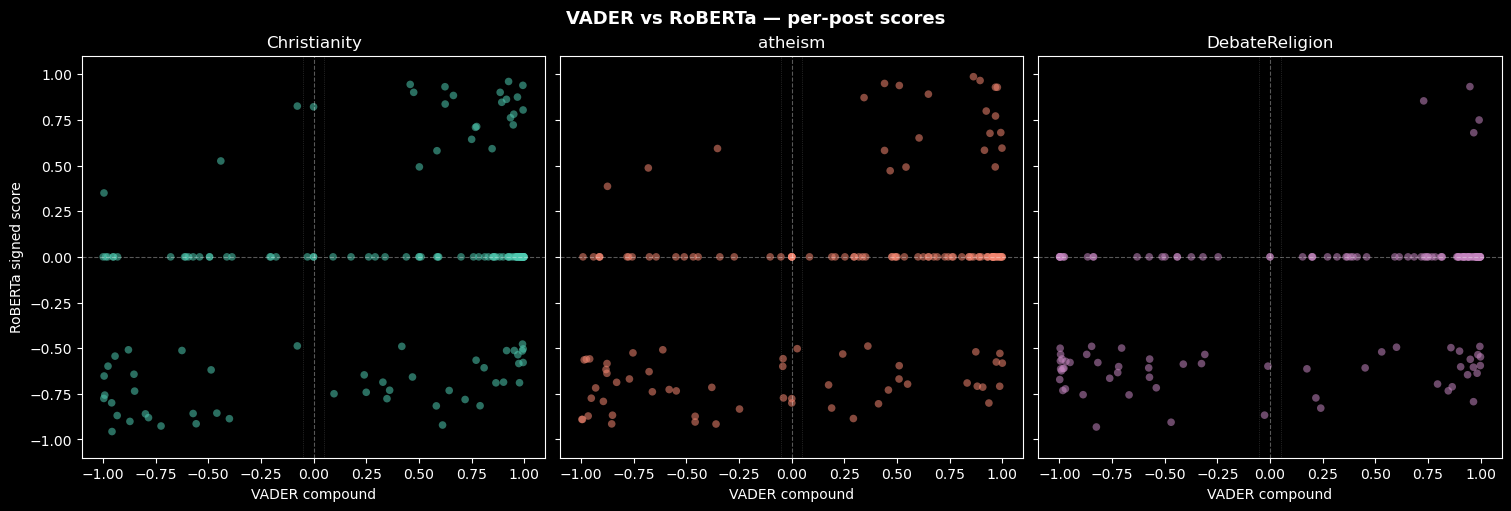

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True, constrained_layout=True)
fig.suptitle("VADER vs RoBERTa — per-post scores", fontsize=13, weight="bold")

for ax, sub in zip(axes, SUBREDDITS):
    mask = df_all["subreddit"] == sub
    ax.scatter(
        df_all.loc[mask, "vader_compound"],
        df_all.loc[mask, "roberta_signed"],
        color=SUB_COLORS[sub], alpha=0.55, s=30, edgecolors="none",
    )
    ax.axvline( 0,    color="white", lw=0.8, ls="--", alpha=0.35)
    ax.axhline( 0,    color="white", lw=0.8, ls="--", alpha=0.35)
    ax.axvline( 0.05, color="white", lw=0.5, ls=":",  alpha=0.25)
    ax.axvline(-0.05, color="white", lw=0.5, ls=":",  alpha=0.25)
    ax.set_title(sub)
    ax.set_xlabel("VADER compound")

axes[0].set_xlim(-1.1, 1.1)
axes[0].set_ylim(-1.1, 1.1)
axes[0].set_ylabel("RoBERTa signed score")
plt.show()

In [10]:
N_EXAMPLES = 2

print("VADER — example posts per subreddit × sentiment class\n")

for sub in SUBREDDITS:
    for label in LABELS:
        mask   = (df_all["subreddit"] == sub) & (df_all["vader_label"] == label)
        n      = mask.sum()
        sample = df_all[mask].sample(n=min(N_EXAMPLES, n), random_state=RANDOM_SEED)
        print(f"── r/{sub}  [{label}]  ({n} posts total)")
        print("─" * 80)
        for _, row in sample.iterrows():
            print(f"compound: {row['vader_compound']:+.3f}")
            print(row["text"])
            print()
        print()

VADER — example posts per subreddit × sentiment class

── r/Christianity  [positive]  (102 posts total)
────────────────────────────────────────────────────────────────────────────────
compound: +0.999
"The capacity to have done otherwise under the exact same circumstances, of which there are infinite factors. Most libertarian free willers will say that this is true, yet then they also claim that it's not magic. It's just simply that they're "able to do it, and everyone is," which is the heavy absurdity towards the less fortunate. Persuasion by privilege. Most compatibilists will either argue that free will is simply the definition of will, but for some reason they throw the word free in front of it, or from some sort of legalistic standpoint in regards to free will and such is why determinism still fits, or they are very much inclined towards the libertarian position as well themselves, yet in some sort of fluid uncertain disguise. ... All things and all beings act in accordance to an

In [11]:
print("RoBERTa — example posts per subreddit × sentiment class\n")

for sub in SUBREDDITS:
    for label in LABELS:
        mask   = (df_all["subreddit"] == sub) & (df_all["roberta_label"] == label)
        n      = mask.sum()
        sample = df_all[mask].sample(n=min(N_EXAMPLES, n), random_state=RANDOM_SEED)
        print(f"── r/{sub}  [{label}]  ({n} posts total)")
        print("─" * 80)
        for _, row in sample.iterrows():
            print(f"score: {row['roberta_score']:.3f}")
            print(row["text"])
            print()
        print()

RoBERTa — example posts per subreddit × sentiment class

── r/Christianity  [positive]  (25 posts total)
────────────────────────────────────────────────────────────────────────────────
score: 0.762
The Bible Project on youtube seems to be one of the most popular if not the most popular christian channels. They have a series of original word study videos that show how important it is to remember the english bibles are translations and none of them capture the full picture 100% of the time. https://www.youtube.com/playlist?list=PLH0Szn1yYNeclOdfwWBawnNT5ZkGFHxBf That is their playlist of 13 videos on original word studies. If you find those valuable there is a subreddit that talks a lot about this topic /r/originalchristianity Here is another playlist of original word studies by another ministry.Not quite as good as The Bible Project but you can still learn some good info. https://www.youtube.com/playlist?list=PLo5QtZ1bPyYZehuDmvGlgh3I6HmWAqQ3F

score: 0.822
If anyone is looking for a b